# PRUEBA MEJOR MODELO.
## Grupo 2

### Importacón de librerías.

In [1]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch
from sklearn.metrics import accuracy_score
import tensorflow as tf
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from torchvision import transforms

### Redimensionando los datos creados.

In [2]:
# Dirección y dimensiones.
test_dir = Path('test_creado')
DIM_IMAGEN = (64, 64)

# Buscar jpg y jpeg, sin importar mayúsculas/minúsculas
images = [image_path for image_path in test_dir.iterdir() if image_path.is_file() and image_path.suffix.lower() in {".jpg", ".jpeg"}]

print(f"Imágenes encontradas: {len(images)}")

for image_path in images:
    try:
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = image.resize(DIM_IMAGEN, resample=Image.Resampling.LANCZOS)

            # Sobrescribe la imagen original
            nueva_ruta = image_path.with_suffix(".jpg")

            image.save(nueva_ruta, format="JPEG", quality=95)

    except Exception as e:
        print(f"Error con {image_path.name}: {e}")

Imágenes encontradas: 15


### Carga del modelo.

In [3]:
model = nn.Sequential(

    # 3x64x64 -> 16x64x64
    nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 16x32x32
    nn.MaxPool2d(
        kernel_size=2,
        stride=2
    ),

    # -> 32x32x32
    nn.Conv2d(
        16,
        32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 32x16x16
    nn.MaxPool2d(2),

    # -> 64x16x16
    nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    # -> 64x8x8
    nn.MaxPool2d(2),

    # 64x8x8 -> 4096
    nn.Flatten(),

    nn.Linear(
        64 * 8 * 8,
        128
    ),
    nn.ReLU(),

    nn.Linear(
        128,
        29
    )
)
model.load_state_dict(torch.load("modelo2_cnn.pth", map_location="cpu"))

<All keys matched successfully>

### Importando el conjunto de prueba.

In [4]:
# Listado de rutas de imágenes.
imagenes_test = list(test_dir.glob("*.jpg"))
nombres_imagenes_test = [str(texto).rsplit('\\', 1)[-1] for texto in imagenes_test]

# Clases
clases = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'K', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
class_to_idx = {c:i for i,c in enumerate(clases)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

# Etiquetas test
etiquetas_test = []
for x in nombres_imagenes_test:
    etiquetas_test.append(x[0])
etiquetas_test = np.array(etiquetas_test)
test_labels = np.array([class_to_idx[x] for x in etiquetas_test], dtype=np.int32)


transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])


X_test_lista = []
for ruta in imagenes_test:

    # Cargar exactamente como en ASLDataset
    imagen = Image.open(ruta).convert("RGB")
    imagen = transform_test(imagen)
    X_test_lista.append(imagen)


X_test = torch.stack(X_test_lista)
y_test = test_labels

### Predicción del modelo.

In [5]:
# Convertimos X_test a tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# Modo evaluación
model.eval()

# Se calcula la predicción.
with torch.no_grad():
    outputs = model(X_test_tensor)
    y_pred = torch.argmax(outputs, dim=1)

# Convertimos las predicciones a numpy
y_pred = y_pred.cpu().numpy()

C:\Users\ricro\AppData\Local\Temp\ipykernel_22824\962095690.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [6]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predicciones:")
print(y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Predicciones:
[11 11  2  2 14 14 25  2 25  2  2 15 15  6  5]

Accuracy: 0.0667
Accuracy: 6.67%


### Matriz de confusión.

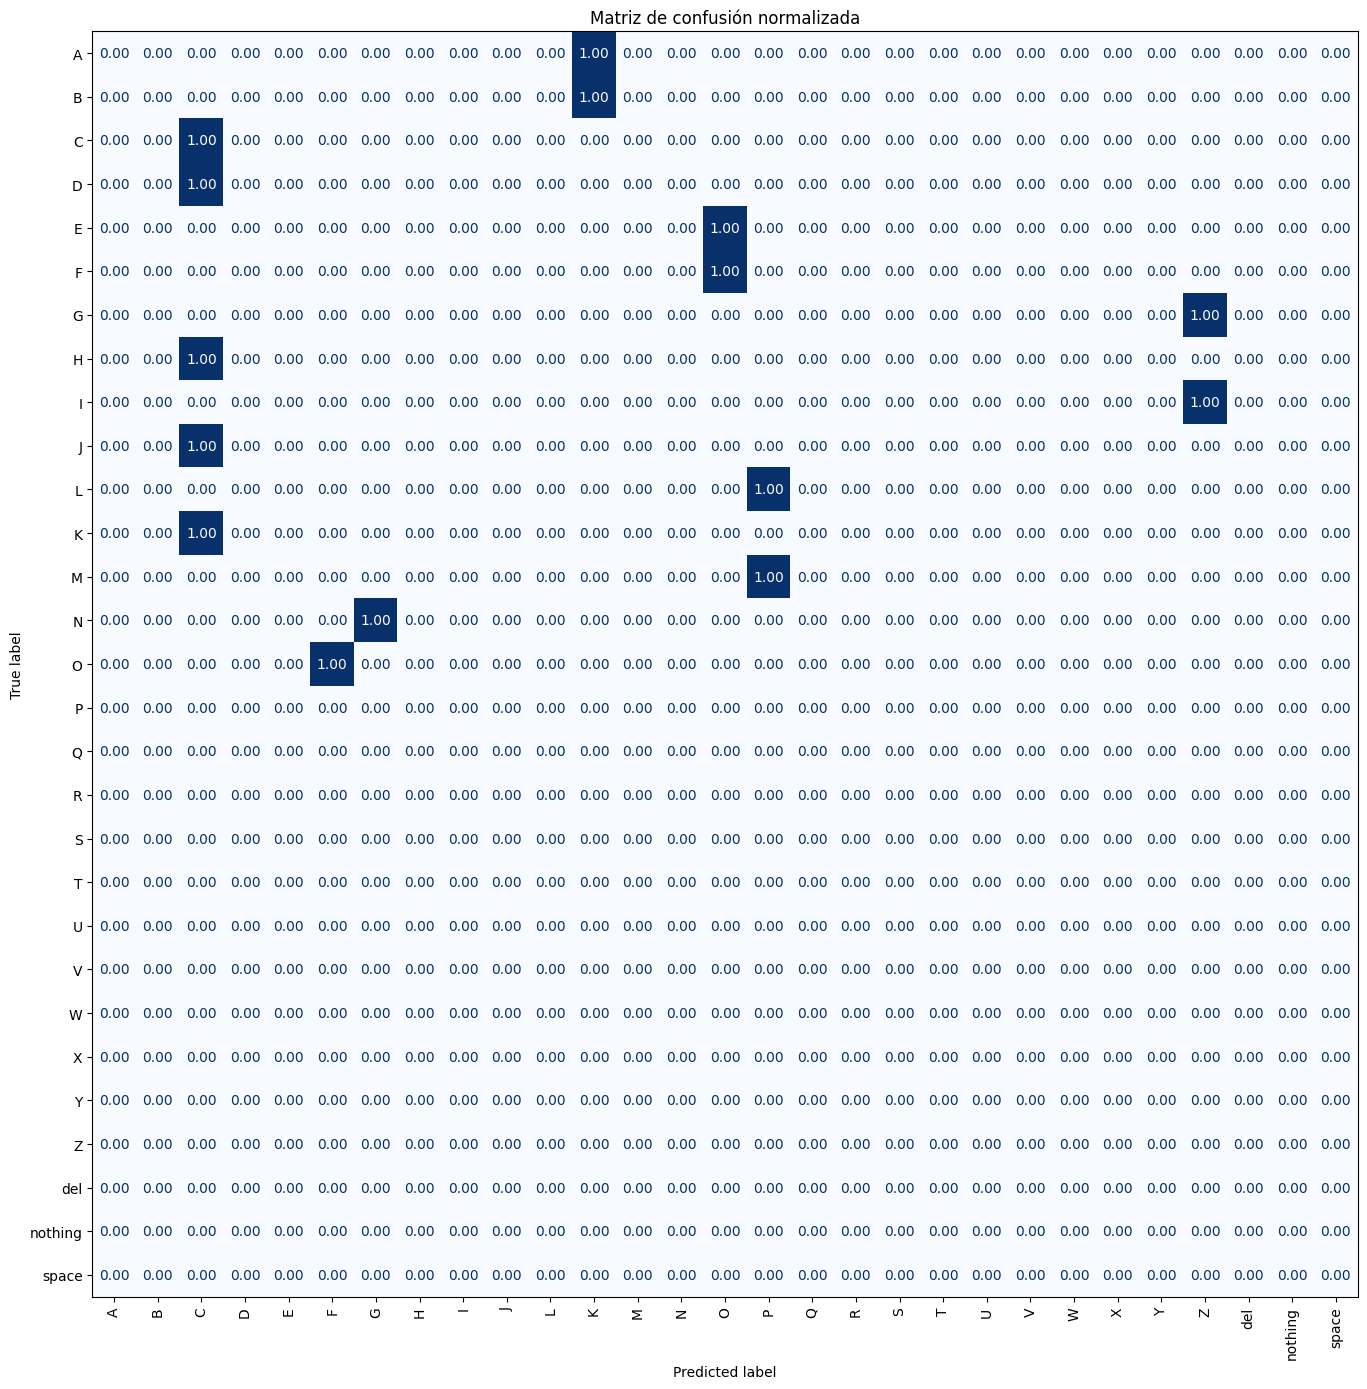

In [8]:
cm_norm = confusion_matrix(y_test, y_pred, labels=np.arange(29), normalize="true")
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=[idx_to_class[i] for i in range(29)])
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format=".2f", colorbar=False)
plt.title("Matriz de confusión normalizada")
plt.tight_layout()
plt.show()

### Conjunto creado.

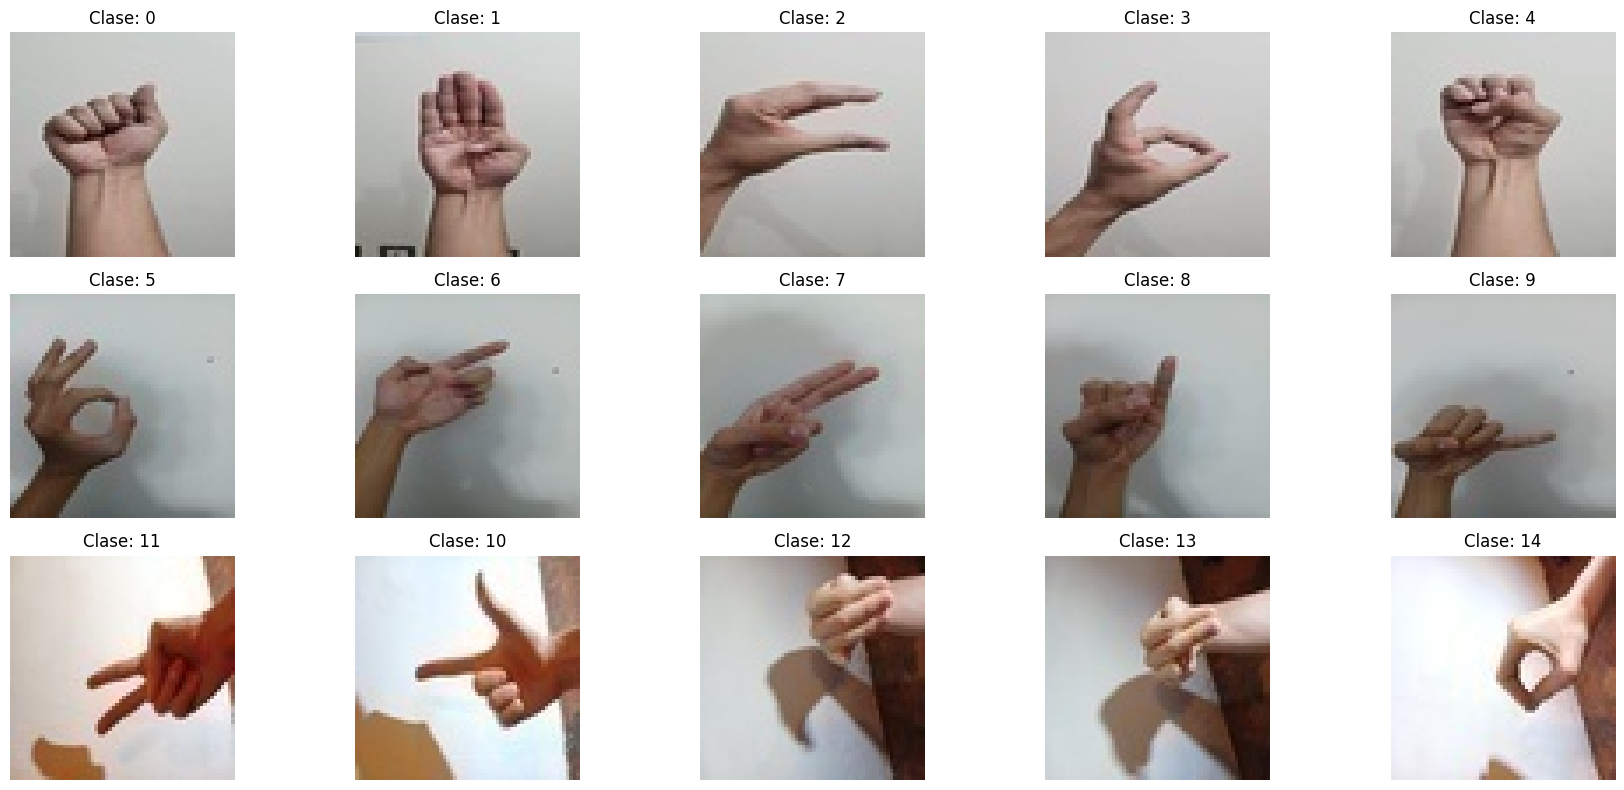

In [51]:
import matplotlib.pyplot as plt

n_imagenes = 15

plt.figure(figsize=(18, 8))

for i in range(len(X_test_imagen)):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test_imagen[i])
    plt.title(f"Clase: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Discusión.
El mejor modelo no lo hizo bien, puede que se haya visto muy afectado por los fondos utilizados, el color de las manos, las sombras e incluso por el tamaño de las manos. Solo pudo identificar correctamente la letra C, por lo que se deben entrenar el modelo con una mayor cantidad de datos, priorizando colores de fondo, colores de manos, sombras e incluso mano izquierda y derecha, entre otros.